In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
display(HTML("<style>.container { font-size:18px !important; }</style>"))


from astropy.io import fits
from scipy.ndimage import zoom
from scipy.signal import convolve2d
from scipy import interpolate
from scipy.interpolate import RegularGridInterpolator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\HP\AppData\Local\Temp\ipykernel_5384\130177696.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


**PRIMER PROBLEMA**

Siguiendo el método visto en clase, utilice las variaciones temporales de la pantalla de fase (archivo pscreen-512x512x100.fits) para calcular la imagen del Sol, degradada por la PSF atmosférica, en cada uno de estos 100 pasos de tiempo. Las pantallas de fase se han generado para una apertura de 1 m × 1 m, por lo que, en principio, no se pueden usar para telescopios de más de 1 m de diámetro.

Text(0.5, 1.0, 'Apertura\xa0(1\xa0m)')

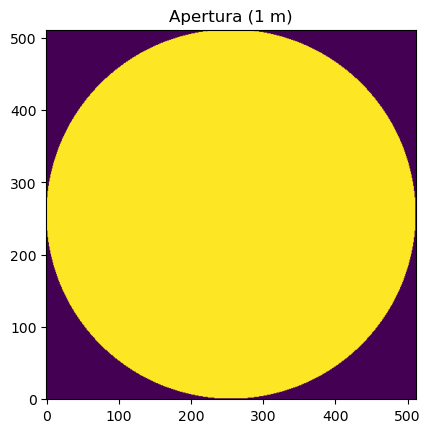

In [4]:
# Crear la apertura del telescopio según el phase screen (512×512, apertura 1 m)

N = 512  # número de puntos en el phase screen
a = 1.0  # tamaño físico total del pupil (1 m)
R = 0.5  # radio del telescopio (apertura de 1 m)

aperture = np.zeros((N, N))

# grid físico en metros
x = np.linspace(-a/2, a/2, N)
y = np.linspace(-a/2, a/2, N)

# construir la apertura circular
for i in range(N):
    for j in range(N):
        if np.sqrt(x[i]**2 + y[j]**2) <= R:
            aperture[i, j] = 1.0

plt.imshow(aperture, origin='lower')
plt.title("Apertura (1 m)")


Shape de las pantallas de fase: (100, 512, 512)
Shape de la apertura: (512, 512)


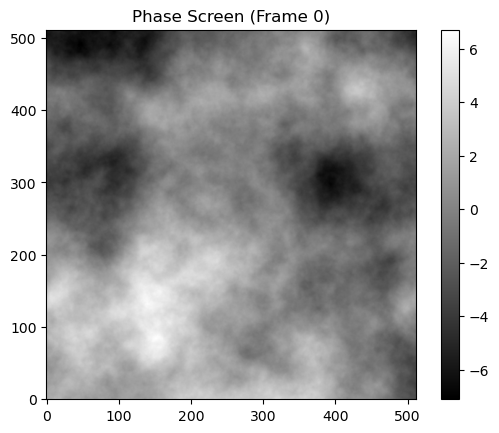

In [5]:
# Leer pantallas de fase
phase = fits.open("pscreen-512x512x100.fits")[0].data
print("Shape de las pantallas de fase:", phase.shape)   # debería ser (100, 512, 512)

scale = N / phase.shape[1]
phase_interp = zoom(phase, (1, scale, scale))

# Verificar que coincida con la apertura
print("Shape de la apertura:", aperture.shape)

# Si la fase está en OPD (metros), descomenta y pon tu λ:
# wavelength = 500e-9  # ejemplo para 500 nm
# phase = (2*np.pi/ wavelength) * phase

# Visualizar la primera pantalla (sin interpolación)
plt.imshow(phase[0], origin='lower', cmap='gray')
plt.title("Phase Screen (Frame 0)")
plt.colorbar()
plt.show()

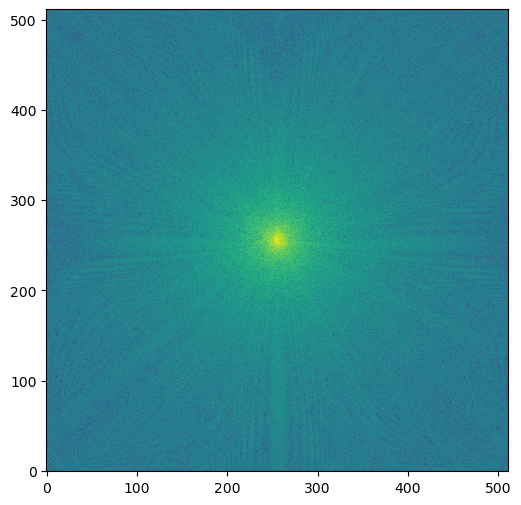

In [6]:
# phase_interp *= np.pi/180.0

aperture_complex = aperture * np.exp(1j * phase_interp[0])

# FFT para obtener la PSF
aperture_fft = np.fft.fft2(aperture_complex)
PSF1 = np.abs(aperture_fft)**2

# Centrar PSF
PSF1 = np.fft.fftshift(PSF1)

# Recortamos la PSF al tamaño pequeño
N_small = 200
PSF_small = PSF1[N//2-N_small//2:N//2+N_small//2,
                N//2-N_small//2:N//2+N_small//2]

# Graficamos la PSF logarítmica
plt.figure(figsize=(6,6))
plt.imshow(np.log10(PSF1), origin='lower')
plt.show()

In [7]:
# ------------------------------
# Definir grid de frecuencias y PSF
# ------------------------------
x_step = a / N
xf = np.linspace(-1.0/(2.0*x_step), 1.0/(2.0*x_step), N)
llambda = 630e-9  # longitud de onda
theta = xf * llambda * 206265  # transformar a arcsec

N_small = 200
theta_small = theta[N//2 - N_small//2 : N//2 + N_small//2]

# Grid del Sol para interpolar la PSF
scale_grid = 48.0/725.0
grid_interpolate = np.linspace(-31.5,31.5,64)*scale_grid

In [8]:
image = fits.open("synth_sun.fits")[0].data
contrasts = []
images_smeared = []

for frame in range(phase_interp.shape[0]):
    
    # Apertura compleja
    aperture_complex = aperture * np.exp(1j * phase_interp[frame])
    
    # FFT → PSF
    PSF1 = np.fft.fft2(aperture_complex)
    PSF1 = np.abs(PSF1)**2
    PSF1 = np.fft.fftshift(PSF1)
    
    # Recortar al tamaño pequeño
    PSF_small = PSF1[N//2-N_small//2:N//2+N_small//2,N//2-N_small//2:N//2+N_small//2]
    PSF_small /= np.sum(PSF_small)
    
    # Interpolación al grid del Sol usando RegularGridInterpolator
    interp_func = RegularGridInterpolator(
        (theta_small, theta_small),  # ejes originales de PSF
        PSF_small,
        bounds_error=False,
        fill_value=0.0
    )
    
    # Crear malla de puntos de destino
    grid_x, grid_y = np.meshgrid(grid_interpolate, grid_interpolate)
    points = np.array([grid_x.flatten(), grid_y.flatten()]).T
    
    # Interpolar
    psf_interpolated = interp_func(points).reshape(grid_x.shape)
    psf_interpolated /= np.sum(psf_interpolated)  # normalizar

     # Convolución con la imagen
    image_smeared = convolve2d(image, psf_interpolated, mode='same', boundary='symm')
    
    # Normalizar para calcular contraste
    image_norm = image_smeared / np.mean(image_smeared)
    contrast = np.std(image_norm)
    
    contrasts.append(contrast)
    images_smeared.append(image_smeared)


In [9]:
# ------------------------------
# Imagen sumada y contraste
# ------------------------------
image_sum = np.sum(np.array(images_smeared), axis=0)
image_sum /= np.mean(image_sum)
contrast_sum = np.std(image_sum)

print("Contraste de la imagen sumada:",contrast_sum)

Contraste de la imagen sumada: 0.04353320667845038


**Plot de variaciones del contraste de la imagen con el tiempo**

Como es bien conocido, el contraste es una medida de cuánta estructura fina conserva la imagen después de ser afectada por la turbulencia atmosférica. Por tanto, la curva de contraste representa cómo varía en el tiempo la calidad de la imagen del Sol debido a las fluctuaciones atmosféricas. En este caso se utilizaron 100 pantallas de fase que simulan la evolución temporal del seeing.

Se observa un máximo de contraste alrededor del frame 38, lo que indica un periodo de seeing relativamente bueno. Luego ocurre una caída pronunciada entre los frames 50 y 65, donde la atmósfera presenta condiciones altamente turbulentas. Posteriormente, el contraste se recupera parcialmente.



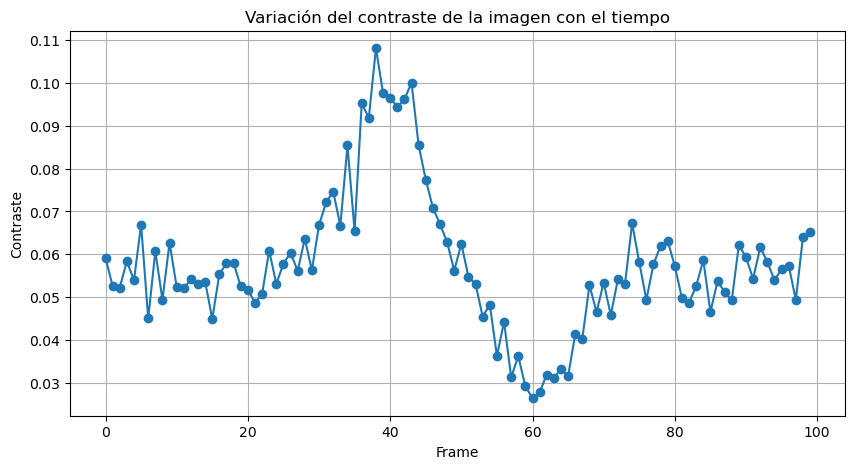

In [12]:
# ------------------------------
# 1) Variación del contraste con el tiempo
# ------------------------------
plt.figure(figsize=(10,5))
plt.plot(contrasts, '-o')
plt.xlabel("Frame")
plt.ylabel("Contraste")
plt.title("Variación del contraste de la imagen con el tiempo")
plt.grid(True)
plt.show()

**Comparación con el parámetro de Fried $r_0$**

El parámetro de Fried es fundamental en astronomía observacional, pues determina directamente la calidad del seeing y la capacidad de un telescopio para conservar la estructura fina de la imagen. En términos prácticos, 
$𝑟_0$ caracteriza cuánta porción del frente de onda puede considerarse libre de deformaciones significativas al atravesar la atmósfera, y por tanto, cuánta información espacial de alta frecuencia puede recuperarse en la imagen final.

En este estudio, la comparación entre el contraste de las imágenes simuladas y los valores de 𝑟0 muestra una correlación directa: **cuando el parámetro de Fried aumenta, indicando un seeing más estable, el contraste también se incrementa**. Por el contrario, una disminución en $𝑟_0$ —producto de una atmósfera más turbulenta— se traduce en una reducción notable en el contraste debido a la pérdida de detalles finos.

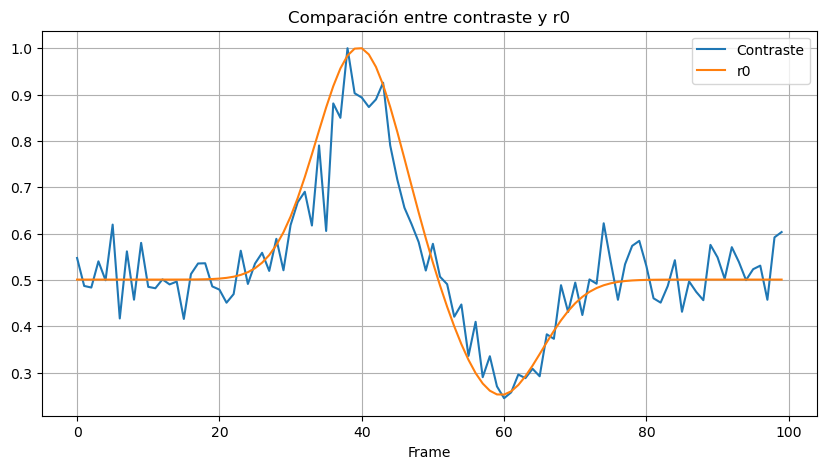

In [15]:
# ------------------------------
# 2) Comparación con variación de r0
# ------------------------------
r0 = fits.getdata("r0s.fits") # parámetro de Fried

plt.figure(figsize=(10,5))
plt.plot(contrasts/np.max(contrasts), label="Contraste")
plt.plot(r0/np.max(r0), label="r0")
plt.legend()
plt.xlabel("Frame")
plt.title("Comparación entre contraste y r0")
plt.grid(True)
plt.show()

**Sume todas las imágenes y calcula el contraste resultante. Compáralo con el contraste de cada imagen individual. Intenta estimar qué apertura del telescopio debería proporcionar el mismo contraste.**

Se calculó el contraste de cada una de las 100 imágenes degradadas por las 
pantallas de fase, obteniéndose valores individuales en el rango de $0.026-0.108$, esto quiere decir que se tiene imagenes de muy bajo ruido hasta muy ruidosas. 


In [18]:
# ------------------------------
# 2) Obtener el contraste de cada imagen individual
# ------------------------------
contraste = []   # aquí guardaremos los contrastes individuales

for img in images_smeared:
    img_norm = img / np.mean(img)   # normalizar
    c = np.std(img_norm)     # sigma/mu (mu=1 después de la normalización)
    contraste.append(c)


df_contrastes = pd.DataFrame({
    "frame": range(len(contraste)),
    "contraste": contraste
})


In [19]:
df_contrastes["contraste"].min(), df_contrastes["contraste"].max()

(0.026425294978211653, 0.10806278681370762)

Al sumar las 100 imágenes individuales se obtiene un contraste global de $0.0435$, un valor ligeramente menor que el contraste individual promedio ($0.0576$) pero situado dentro del rango de variación temporal.

In [21]:
# ------------------------------
# 3) Sumar todas las imágenes y calcular contraste
# ------------------------------
stacked_image = np.sum(images_smeared, axis=0)
stacked_image /= len(images_smeared)

stacked_norm = stacked_image/np.mean(stacked_image)
contrast_stacked = np.std(stacked_norm)

print("Contraste individual medio: ",np.mean(contrasts))
print("Contraste imagen sumada: ",contrast_stacked)

Contraste individual medio:  0.057624124282475014
Contraste imagen sumada:  0.04353320667845038


Este contraste de resultante, evidencia que la señal coherente se preserva, pero la estructura fina —que varía rápidamente de un frame a otro— se atenúa, produciendo una reducción del contraste final. En consecuencia, la imagen sumada muestra un aspecto más suave y borroso, en la que ya no es posible distinguir detalles de la granulación solar debido al efecto acumulado del seeing.

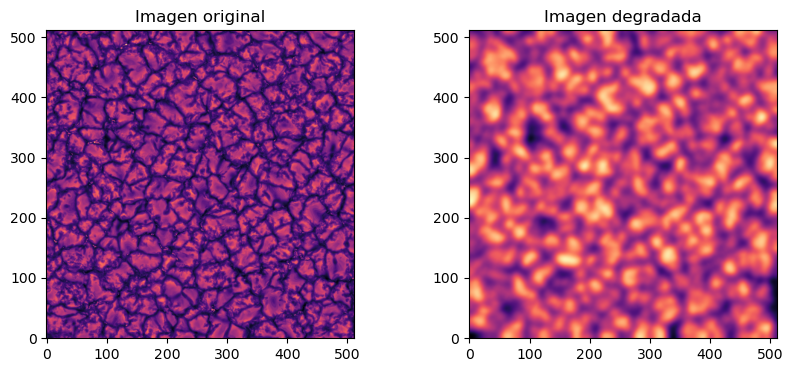

In [23]:
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.imshow(image/np.mean(image), origin='lower', cmap='magma')
plt.title("Imagen original")
plt.subplot(122)
plt.imshow(image_sum, origin='lower', cmap='magma')
plt.title("Imagen degradada")
plt.show()

se estimó la apertura equivalente del telescopio que produciría ese mismo nivel de degradación bajo un régimen dominado por turbulencia atmosférica. Esta estimación se realizó utilizando la relación teórica entre el contraste y el parámetro de Fried $r_0$, que describe el tamaño de la región de coherencia de la atmósfera. Asumiendo el valor promedio de $r_0$ durante la secuencia y aplicando la siguiente formula: 

$$C \;\propto\; \left( \frac{r_0}{D} \right)^{5/6}$$

Se despejó la apertura 𝐷 y se obtuvo una apertura equivalente de ≈ 4.6 metros, la cual indica que la imagen final posee un nivel de suavizado espacial comparable al que tendría un telescopio real de ese diámetro observando bajo las mismas condiciones de seeing promedio.

In [25]:
# ------------------------------
# 4) Estimar apertura equivalente
# ------------------------------
# Usamos el r0 promedio
r0_mean = np.mean(r0)

D_equiv = r0_mean * (1/contrast_stacked)**(6/5)


print("Apertura equivalente que da ese contraste (m):",D_equiv)

Apertura equivalente que da ese contraste (m): 4.620281648169641


**SEGUNDO PROBLEMA**

En esta parte, omitiremos los efectos de la atmósfera. Utilizando la imagen sintética del Sol proporcionada y calculando la PSF como hicimos en la práctica, intente deconvolucionar la imagen distorsionada y obtener la original.

In [28]:
# FFT de la apertura
aperture_fft = np.fft.fft2(aperture)

# PSF = |FFT|^2
PSF = np.abs(aperture_fft)**2

# CENTRAR LA PSF SOLO PARA VISUALIZACIÓN
PSF_shifted = np.fft.fftshift(PSF)

# Normalizar para deconvolución
PSF_shifted /= PSF_shifted.sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_5384\2355115377.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(PSF_shifted), origin='lower')


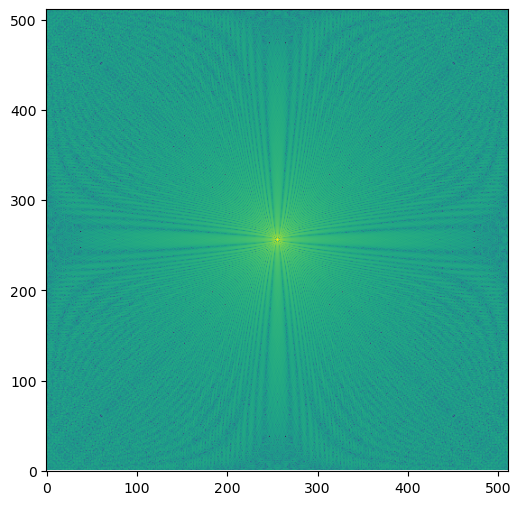

In [29]:
# we plot psf in the log scale
plt.figure(figsize=(6,6))
plt.imshow(np.log10(PSF_shifted), origin='lower')


In [30]:
print(theta.min(), theta.max())

interp = RegularGridInterpolator((theta, theta), PSF)

# Crear la grilla interpolada
grid_interpolate = np.linspace(theta.min(), theta.max(), 64)
X_new, Y_new = np.meshgrid(grid_interpolate, grid_interpolate)
points = np.array([X_new.ravel(), Y_new.ravel()]).T
psf_interpolated = interp(points).reshape(X_new.shape)

# Preparar puntos para evaluación
points = np.array([X_new.ravel(), Y_new.ravel()]).T

# Interpolar
psf_interpolated = interp(points).reshape(X_new.shape)

-33.2664192 33.2664192


In [31]:
# we have to normalize again so that the surface of the psf is one
psf_interpolated /= np.sum(psf_interpolated)

image_smeared = convolve2d(image,psf_interpolated,mode='same',boundary='symm')

mean = np.mean(image)
image /= mean
image_smeared /=mean


Para la deconvolución se implementó el **método de Wiener** usando transformadas de Fourier. Primero se normaliza la PSF y se calcula la transformada de Fourier tanto de la imagen borrosa como de la PSF. En el dominio frecuencial, la convolución se convierte en una multiplicación, por lo que la imagen original puede recuperarse dividiendo ambas transformadas. Sin embargo, para evitar la amplificación del ruido en las frecuencias donde la PSF tiene valores muy pequeños, se introduce un término de regularización 
𝜖, propio del filtro de Wiener.

In [72]:
# Imagen observada
image_blur = images_smeared[0]

# Usar la PSF SIN SHIFT para deconvolución
PSF_for_deconv = PSF / PSF.sum()  # PSF original sin shift

# FFT de la imagen (sin shift)
F_blur = np.fft.fft2(image_blur)

# FFT de la PSF (sin shift)
F_psf = np.fft.fft2(PSF_for_deconv)

# Parámetro de regularización - prueba diferentes valores
eps = 1e-6

# Filtro de Wiener
F_deconv = F_blur * np.conj(F_psf) / (np.abs(F_psf)**2 + eps)


# Reconstrucción
image_deconv = np.abs(np.fft.ifft2(F_deconv))


La imagen deconvolucionada que se obtiene no mejora significativamente respecto a la degradada, se calcula una diferencia de contraste de tan sólo $0.0018$.

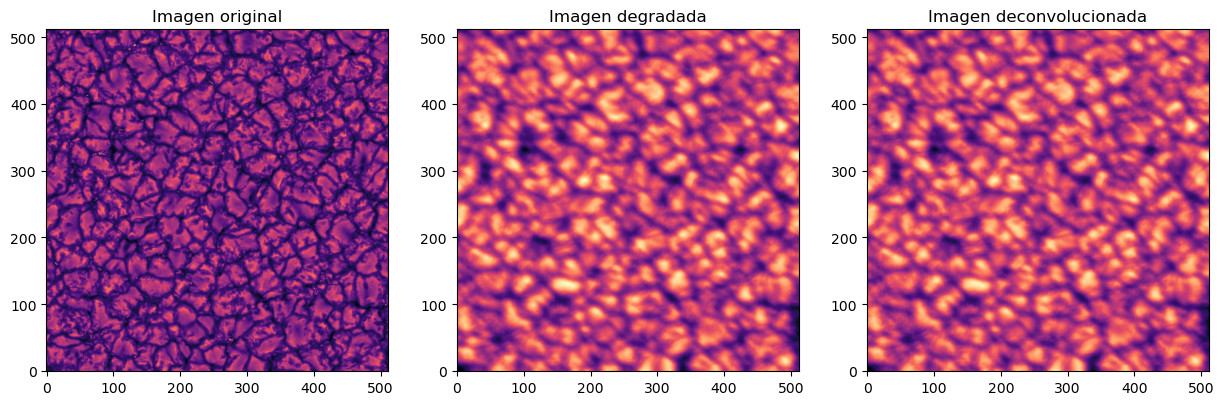

In [74]:
plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(image, origin='lower', cmap='magma')
plt.title("Imagen original")

plt.subplot(132)
plt.imshow(image_blur, origin='lower', cmap='magma')
plt.title("Imagen degradada")

plt.subplot(133)
plt.imshow(image_deconv, origin='lower', cmap='magma')
plt.title("Imagen deconvolucionada")

plt.show()


In [76]:
def contraste(img):
    return np.std(img) / np.mean(img)

C_deg   = contraste(image_blur)
C_wien  = contraste(image_deconv)

print("Contraste degradada:      ", C_deg)
print("Contraste deconvolucionada:", C_wien)


Contraste degradada:       0.05913055554135509
Contraste deconvolucionada: 0.060931184899994564
